### Trend umiejętności dla analityka danych

##### załadowane danych i wstępne oczyszczenie danych

In [1]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
from datasets import load_dataset

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

#loading data
datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(clean_list)

wybranie danych tylko dla analityka danych 

In [2]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

Ilość umiejętności w ogłoszeniach w każdym miesiącu

* dodanie kolumn z miesiącami

In [3]:
df_DA['job_posted_number'] = df_DA['job_posted_date'].dt.strftime('%m')
df_DA_skills = df_DA.explode('job_skills')

* grupowanie po miesiącach, sortowanie po numerach miesięcy i usunięcie zbędnego indexu

In [4]:
skills_pivot_df = df_DA_skills.pivot_table(index='job_posted_number', columns='job_skills', aggfunc='size', fill_value=0)
skills_pivot_df


job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_number,,,,,,,,,,,,,,,,,,,,,
01,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
02,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
03,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
04,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
05,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
06,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
07,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
08,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
09,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


* wybór top 5 umiejętności

In [5]:
skills_pivot_df.loc['total'] = skills_pivot_df.sum()
skills_pivot_df.sort_values(by='total', axis=1, ascending=False, inplace=True)
skills_pivot_df


job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_number,,,,,,,,,,,,,,,,,,,,,
01,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,1,0,0,0,0,0,0,0,0,0
02,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
03,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,0,0,0,0,0,0,0,0,0,1
04,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,0,0,0,0,0
05,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,1,0,0,0,0
06,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,0,0,1,0,0,1,1,0,0
07,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
08,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
09,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [6]:
total_posted_jobs = df_DA.groupby('job_posted_number').size()
total_posted_jobs

job_posted_number
01    8494
02    6124
03    6218
04    6049
05    4993
06    5683
07    5201
08    6634
09    4639
10    5271
11    4531
12    3979
dtype: int64

In [7]:
skills_pivot_df = skills_pivot_df.div(total_posted_jobs/100, axis=0)
skills_pivot_df.drop('total', inplace=True)
skills_pivot_df

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_number,,,,,,,,,,,,,,,,,,,,,
01,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.011773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
02,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
03,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082
04,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
05,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028,0.000000,0.000000,0.000000,0.000000
06,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.000000,0.000000,0.017596,0.000000,0.000000,0.017596,0.017596,0.000000,0.000000
07,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
08,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
09,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


* zmiana miesięcy z zapisu liczbowego na słowny

In [8]:
skills_pivot_df = skills_pivot_df.reset_index()
skills_pivot_df['job_posted_month'] = skills_pivot_df['job_posted_number'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
skills_pivot_df.set_index('job_posted_month', inplace=True)
skills_pivot_df.drop(columns='job_posted_number', inplace=True)

* wartości procentowe dla każdej umiejętności w każdym miesiącu

##### Wykres

In [9]:
top_5_skills = skills_pivot_df.iloc[:, :5]

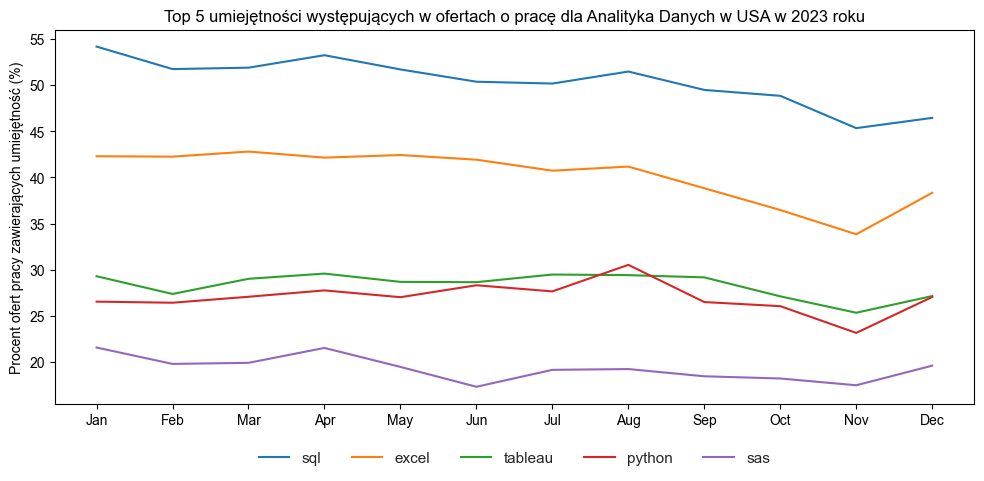

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=top_5_skills, dashes=False, palette='tab10')
sns.set_theme(style="ticks")
sns.move_legend( ax, loc='lower center', title='', bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False)
plt.title('Top 5 umiejętności występujących w ofertach o pracę dla Analityka Danych w USA w 2023 roku')
plt.xlabel('')
plt.ylabel('Procent ofert pracy zawierających umiejętność (%)')
plt.tight_layout()
plt.show()